# Install and Import Libraries

In [2]:
# Install required packages
!pip install nibabel scikit-image -q

# Import libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from glob import glob
import nibabel as nib
from sklearn.model_selection import train_test_split
import cv2
from tqdm import tqdm
import warnings
import time
warnings.filterwarnings('ignore')

# Deep Learning Libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, Model
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau, Callback
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import Sequence
import tensorflow.keras.backend as K

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("="*70)
print("✅ ALL LIBRARIES IMPORTED SUCCESSFULLY")
print("="*70)
print(f"TensorFlow Version: {tf.__version__}")
print(f"GPU Available: {len(tf.config.list_physical_devices('GPU'))} GPU(s)")
print("="*70)

✅ ALL LIBRARIES IMPORTED SUCCESSFULLY
TensorFlow Version: 2.20.0
GPU Available: 1 GPU(s)


# Configuration

In [3]:
# Configuration
class Config:
    # Paths - SAME AS YOUR VIT NOTEBOOK
    TRAIN_PATH = "/mnt/d/Segmentation_TF/MICCAI_BraTS2020_TrainingData"
    
    # Preprocessed data paths
    PROCESSED_PATH = '/mnt/d/Segmentation_TF/Processed_data'
    TRAIN_IMAGES_PATH = os.path.join(PROCESSED_PATH, 'train_images.npy')
    TRAIN_MASKS_PATH = os.path.join(PROCESSED_PATH, 'train_masks.npy')
    VAL_IMAGES_PATH = os.path.join(PROCESSED_PATH, 'val_images.npy')
    VAL_MASKS_PATH = os.path.join(PROCESSED_PATH, 'val_masks.npy')
    TEST_IMAGES_PATH = os.path.join(PROCESSED_PATH, 'test_images.npy')
    TEST_MASKS_PATH = os.path.join(PROCESSED_PATH, 'test_masks.npy')
    
    # Model parameters
    IMG_SIZE = 128
    CHANNELS = 4  # T1, T1ce, T2, FLAIR
    NUM_CLASSES = 4  # 0: background, 1: necrotic, 2: edema, 3: enhancing
    BATCH_SIZE = 4 # Reduced for UNETR (larger model)
    EPOCHS = 50
    LEARNING_RATE = 0.0001
    
    # Training parameters - PATIENT-LEVEL SPLIT
    TRAIN_SPLIT = 0.70
    VAL_SPLIT = 0.15
    TEST_SPLIT = 0.15
    SLICE_RANGE = (30, 120)
    
    # UNETR specific parameters
    PATCH_SIZE = 16
    PROJECTION_DIM = 768     
    NUM_HEADS = 12            
    TRANSFORMER_LAYERS = 12   
    TRANSFORMER_UNITS = [1536, 768]  
    DROPOUT = 0.1
    
config = Config()
os.makedirs(config.PROCESSED_PATH, exist_ok=True)

print("="*70)
print("CONFIGURATION FOR UNETR")
print("="*70)
print(f"Image Size: {config.IMG_SIZE}x{config.IMG_SIZE}")
print(f"Channels: {config.CHANNELS}")
print(f"Number of Classes: {config.NUM_CLASSES}")
print(f"Batch Size: {config.BATCH_SIZE}")
print(f"Epochs: {config.EPOCHS}")
print(f"\n🔧 UNETR Parameters:")
print(f"   Patch Size: {config.PATCH_SIZE}x{config.PATCH_SIZE}")
print(f"   Projection Dimension: {config.PROJECTION_DIM}")
print(f"   Number of Attention Heads: {config.NUM_HEADS}")
print(f"   Number of Transformer Layers: {config.TRANSFORMER_LAYERS}")
print(f"   MLP Dimensions: {config.TRANSFORMER_UNITS}")
print(f"   Dropout: {config.DROPOUT}")
print(f"\n📊 Data Split Strategy (PATIENT-LEVEL):")
print(f"   Train: {config.TRAIN_SPLIT*100:.0f}%")
print(f"   Validation: {config.VAL_SPLIT*100:.0f}%")
print(f"   Test: {config.TEST_SPLIT*100:.0f}%")
print("="*70)

CONFIGURATION FOR UNETR
Image Size: 128x128
Channels: 4
Number of Classes: 4
Batch Size: 4
Epochs: 50

🔧 UNETR Parameters:
   Patch Size: 16x16
   Projection Dimension: 768
   Number of Attention Heads: 12
   Number of Transformer Layers: 12
   MLP Dimensions: [1536, 768]
   Dropout: 0.1

📊 Data Split Strategy (PATIENT-LEVEL):
   Train: 70%
   Validation: 15%
   Test: 15%


# Data Loading Functions

In [3]:
def load_nifti(filepath):
    """Load NIfTI file and return numpy array"""
    return nib.load(filepath).get_fdata()

def get_patient_paths(base_path):
    """Get all patient directories"""
    patient_dirs = sorted(glob(os.path.join(base_path, 'BraTS20_Training_*')))
    return patient_dirs

def load_patient_data(patient_dir):
    """Load all modalities and mask for a patient"""
    patient_id = os.path.basename(patient_dir)
    
    # Load modalities
    t1 = load_nifti(os.path.join(patient_dir, f'{patient_id}_t1.nii'))
    t1ce = load_nifti(os.path.join(patient_dir, f'{patient_id}_t1ce.nii'))
    t2 = load_nifti(os.path.join(patient_dir, f'{patient_id}_t2.nii'))
    flair = load_nifti(os.path.join(patient_dir, f'{patient_id}_flair.nii'))
    
    # Load mask (seg file)
    mask = load_nifti(os.path.join(patient_dir, f'{patient_id}_seg.nii'))
    
    # Stack modalities
    image = np.stack([t1, t1ce, t2, flair], axis=-1)
    
    return image, mask

def convert_mask_labels(mask):
    """Convert label 4 to label 3"""
    mask = mask.copy()
    mask[mask == 4] = 3
    return mask

print("✅ Data loading functions defined!")

✅ Data loading functions defined!


# Data Preprocessing Functions

In [6]:
def normalize_image(image):
    """Z-score normalization for each modality"""
    normalized = np.zeros_like(image, dtype=np.float32)
    for i in range(image.shape[-1]):
        modality = image[..., i]
        mean = np.mean(modality)
        std = np.std(modality)
        if std > 0:
            normalized[..., i] = (modality - mean) / std
        else:
            normalized[..., i] = modality - mean
    return normalized

def extract_slices_from_patient(image, mask, slice_range, img_size):
    """Extract and preprocess 2D slices from 3D volume"""
    slices_img = []
    slices_mask = []
    
    start_slice, end_slice = slice_range
    
    for slice_idx in range(start_slice, min(end_slice, image.shape[2])):
        # Extract slice
        img_slice = image[:, :, slice_idx, :]
        mask_slice = mask[:, :, slice_idx]
        
        # Skip if mask is empty (no tumor)
        if np.sum(mask_slice) == 0:
            continue
        
        # Resize
        img_resized = cv2.resize(img_slice, (img_size, img_size), interpolation=cv2.INTER_LINEAR)
        mask_resized = cv2.resize(mask_slice, (img_size, img_size), interpolation=cv2.INTER_NEAREST)
        
        slices_img.append(img_resized)
        slices_mask.append(mask_resized)
    
    return slices_img, slices_mask

def preprocess_dataset_patient_level(patient_paths, slice_range, img_size):
    """Preprocess entire dataset at patient level"""
    all_images = []
    all_masks = []
    
    for patient_dir in tqdm(patient_paths, desc="Processing patients"):
        try:
            # Load patient data
            image, mask = load_patient_data(patient_dir)
            
            # Normalize image
            image = normalize_image(image)
            
            # Convert mask labels
            mask = convert_mask_labels(mask)
            
            # Extract slices
            img_slices, mask_slices = extract_slices_from_patient(image, mask, slice_range, img_size)
            
            all_images.extend(img_slices)
            all_masks.extend(mask_slices)
            
        except Exception as e:
            print(f"Error processing {patient_dir}: {e}")
            continue
    
    # Convert to numpy arrays
    all_images = np.array(all_images, dtype=np.float32)
    all_masks = np.array(all_masks, dtype=np.float32)
    
    return all_images, all_masks

print("✅ Preprocessing functions defined!")

✅ Preprocessing functions defined!


# Split Patients & Process

In [6]:
# --- 1. Setup Directories ---
# Create folders on your F: drive to store the processed files
for split in ['train', 'val', 'test']:
    os.makedirs(os.path.join(config.PROCESSED_PATH, split, 'images'), exist_ok=True)
    os.makedirs(os.path.join(config.PROCESSED_PATH, split, 'masks'), exist_ok=True)

# --- 2. Define the Saving Function ---
def save_slices_to_disk(patient_paths, split_type):
    """Process patients and save individual slices to disk as .npy files"""
    print(f"\n🔄 Processing and saving {split_type} data to disk...")
    count = 0
    
    for patient_dir in tqdm(patient_paths):
        try:
            # Load and preprocess 3D volume
            image, mask = load_patient_data(patient_dir)
            image = normalize_image(image)
            mask = convert_mask_labels(mask)
            
            # Extract 2D slices
            img_slices, mask_slices = extract_slices_from_patient(
                image, mask, config.SLICE_RANGE, config.IMG_SIZE
            )
            
            # Save each slice individually
            for i, (img_s, mask_s) in enumerate(zip(img_slices, mask_slices)):
                filename = f"{os.path.basename(patient_dir)}_slice_{i}.npy"
                
                # Save Image
                save_path_img = os.path.join(config.PROCESSED_PATH, split_type, 'images', filename)
                np.save(save_path_img, img_s)
                
                # Save Mask
                save_path_mask = os.path.join(config.PROCESSED_PATH, split_type, 'masks', filename)
                np.save(save_path_mask, mask_s)
                
                count += 1
                
        except Exception as e:
            print(f"Error processing {patient_dir}: {e}")
            continue
            
    print(f"✅ Finished {split_type}: Saved {count} slices.")
    return count

# --- 3. Execute Split and Save ---
print("="*70)
print("PROCESSING DATA (SAVING TO DISK)")
print("="*70)

# Get all patient paths
all_patient_paths = get_patient_paths(config.TRAIN_PATH)
print(f"Total patients found: {len(all_patient_paths)}")

# Split patients (Same logic as before to prevent leakage)
train_patients, temp_patients = train_test_split(
    all_patient_paths, 
    test_size=(config.VAL_SPLIT + config.TEST_SPLIT),
    random_state=42
)

val_patients, test_patients = train_test_split(
    temp_patients,
    test_size=config.TEST_SPLIT/(config.VAL_SPLIT + config.TEST_SPLIT),
    random_state=42
)

print(f"\n📊 Patient Split:")
print(f"   Training patients: {len(train_patients)}")
print(f"   Validation patients: {len(val_patients)}")
print(f"   Test patients: {len(test_patients)}")

# Run the saving process
n_train = save_slices_to_disk(train_patients, 'train')
n_val = save_slices_to_disk(val_patients, 'val')
n_test = save_slices_to_disk(test_patients, 'test')

print("\n" + "="*70)
print(f"✅ DATA PROCESSING COMPLETE")
print(f"Total Training Slices Saved: {n_train}")
print(f"Total Validation Slices Saved: {n_val}")
print(f"Total Test Slices Saved: {n_test}")
print("="*70)





PROCESSING DATA (SAVING TO DISK)
Total patients found: 369

📊 Patient Split:
   Training patients: 258
   Validation patients: 55
   Test patients: 56

🔄 Processing and saving train data to disk...


100%|██████████| 258/258 [19:54<00:00,  4.63s/it]


✅ Finished train: Saved 15703 slices.

🔄 Processing and saving val data to disk...


100%|██████████| 55/55 [04:27<00:00,  4.86s/it]


✅ Finished val: Saved 3335 slices.

🔄 Processing and saving test data to disk...


100%|██████████| 56/56 [04:23<00:00,  4.71s/it]

✅ Finished test: Saved 3290 slices.

✅ DATA PROCESSING COMPLETE
Total Training Slices Saved: 15703
Total Validation Slices Saved: 3335
Total Test Slices Saved: 3290


# Visualization

📸 VISUALIZING SAMPLES FROM DISK


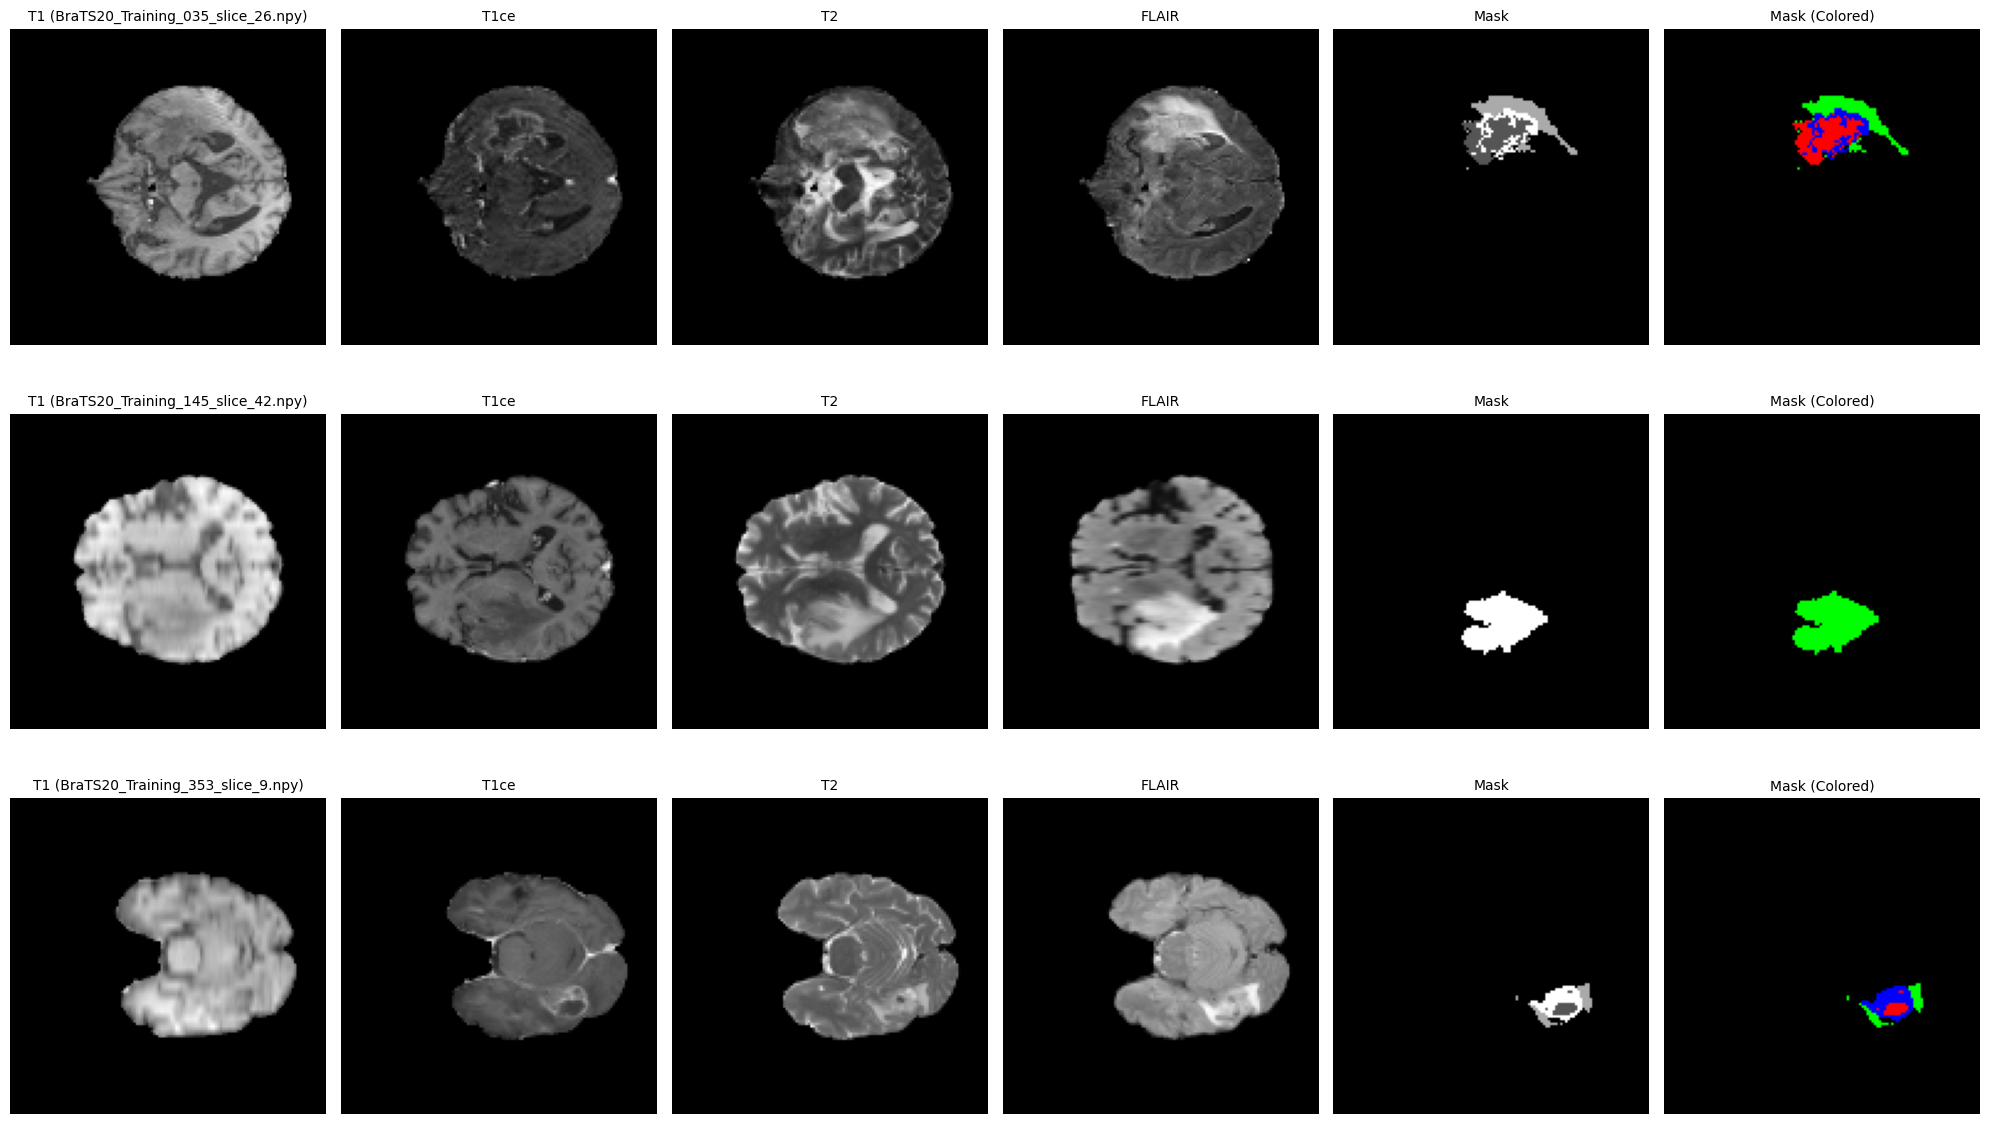

In [7]:
# ==========================================
# NEW CELL 6: Visualize from Disk
# ==========================================
def visualize_from_disk(split_type='train', num_samples=3):
    """Load random samples from disk and visualize them"""
    image_dir = os.path.join(config.PROCESSED_PATH, split_type, 'images')
    mask_dir = os.path.join(config.PROCESSED_PATH, split_type, 'masks')
    
    all_files = os.listdir(image_dir)
    if len(all_files) == 0:
        print("No files found to visualize!")
        return

    indices = np.random.choice(len(all_files), num_samples, replace=False)
    
    # Color map for segmentation mask
    colors = np.array([
        [0, 0, 0],       # 0: Background - Black
        [255, 0, 0],     # 1: Necrotic - Red
        [0, 255, 0],     # 2: Edema - Green
        [0, 0, 255]      # 3: Enhancing - Blue
    ])
    
    fig, axes = plt.subplots(num_samples, 6, figsize=(20, 4*num_samples))
    
    for i, idx in enumerate(indices):
        filename = all_files[idx]
        
        # Load numpy arrays from disk
        img_data = np.load(os.path.join(image_dir, filename))
        mask_data = np.load(os.path.join(mask_dir, filename))
        
        # Plot T1
        axes[i, 0].imshow(img_data[:, :, 0], cmap='gray')
        axes[i, 0].set_title(f'T1 ({filename})', fontsize=10)
        axes[i, 0].axis('off')
        
        # Plot T1ce
        axes[i, 1].imshow(img_data[:, :, 1], cmap='gray')
        axes[i, 1].set_title('T1ce', fontsize=10)
        axes[i, 1].axis('off')
        
        # Plot T2
        axes[i, 2].imshow(img_data[:, :, 2], cmap='gray')
        axes[i, 2].set_title('T2', fontsize=10)
        axes[i, 2].axis('off')
        
        # Plot FLAIR
        axes[i, 3].imshow(img_data[:, :, 3], cmap='gray')
        axes[i, 3].set_title('FLAIR', fontsize=10)
        axes[i, 3].axis('off')
        
        # Plot Mask (grayscale)
        axes[i, 4].imshow(mask_data, cmap='gray')
        axes[i, 4].set_title('Mask', fontsize=10)
        axes[i, 4].axis('off')
        
        # Plot Mask (colored)
        # Create colored mask based on classes
        mask_colored = colors[mask_data.astype(int)]
        axes[i, 5].imshow(mask_colored.astype(np.uint8))
        axes[i, 5].set_title('Mask (Colored)', fontsize=10)
        axes[i, 5].axis('off')
    
    plt.tight_layout()
    plt.show()

print("="*70)
print("📸 VISUALIZING SAMPLES FROM DISK")
print("="*70)
visualize_from_disk('train', num_samples=3)

# Data Generator

In [5]:
class DiskDataGenerator(Sequence):
    """Generator that loads data from disk (saved .npy files) on the fly"""
    def __init__(self, split_type, batch_size, shuffle=True, augment=False):
        self.base_dir = config.PROCESSED_PATH
        self.split_type = split_type
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.augment = augment
        
        # Get list of filenames (we only need image names, masks have matching names)
        self.image_dir = os.path.join(self.base_dir, split_type, 'images')
        self.mask_dir = os.path.join(self.base_dir, split_type, 'masks')
        self.file_list = sorted(os.listdir(self.image_dir))
        
        self.indices = np.arange(len(self.file_list))
        self.on_epoch_end()

    def __len__(self):
        return int(np.floor(len(self.file_list) / self.batch_size))

    def __getitem__(self, idx):
        # Get indices for this batch
        batch_indices = self.indices[idx * self.batch_size:(idx + 1) * self.batch_size]
        
        batch_x = []
        batch_y = []
        
        for i in batch_indices:
            filename = self.file_list[i]
            
            # Load files from disk
            img_path = os.path.join(self.image_dir, filename)
            mask_path = os.path.join(self.mask_dir, filename)
            
            img = np.load(img_path)
            mask = np.load(mask_path)
            
            batch_x.append(img)
            batch_y.append(mask)
            
        batch_x = np.array(batch_x, dtype=np.float32)
        batch_y = np.array(batch_y, dtype=np.float32)
        
        # OPTIONAL: Simple Augmentation (flips/rotations)
        if self.augment:
            batch_x, batch_y = self._augment_batch(batch_x, batch_y)

        # One-hot encode masks on the fly
        batch_y = tf.keras.utils.to_categorical(batch_y, num_classes=config.NUM_CLASSES)
        
        return batch_x, batch_y

    def _augment_batch(self, images, masks):
        """Apply random flips and rotations"""
        for i in range(len(images)):
            if np.random.random() > 0.5: # Horizontal flip
                images[i] = np.flip(images[i], axis=1)
                masks[i] = np.flip(masks[i], axis=1)
            if np.random.random() > 0.5: # Vertical flip
                images[i] = np.flip(images[i], axis=0)
                masks[i] = np.flip(masks[i], axis=0)
            if np.random.random() > 0.5: # Rotate
                k = np.random.randint(1, 4)
                images[i] = np.rot90(images[i], k)
                masks[i] = np.rot90(masks[i], k)
        return images, masks

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

# Create the new generators pointing to your hard drive folders
train_gen = DiskDataGenerator('train', config.BATCH_SIZE, shuffle=True, augment=True)
val_gen = DiskDataGenerator('val', config.BATCH_SIZE, shuffle=False, augment=False)
test_gen = DiskDataGenerator('test', config.BATCH_SIZE, shuffle=False, augment=False)

print("✅ Disk-based data generators created!")
print(f"   Training batches: {len(train_gen)}")
print(f"   Validation batches: {len(val_gen)}")
print(f"   Test batches: {len(test_gen)}")

# Test it immediately
try:
    test_x, test_y = train_gen[0]
    print(f"\n🧪 Generator Test:")
    print(f"   Batch X shape: {test_x.shape}")
    print(f"   Batch Y shape: {test_y.shape}")
    print("✅ Generator is working correctly.")
except Exception as e:
    print(f"\n❌ Generator Failed: {e}")
    print("Check if your 'processed_data' folder contains .npy files.")

✅ Disk-based data generators created!
   Training batches: 3925
   Validation batches: 833
   Test batches: 822

🧪 Generator Test:
   Batch X shape: (4, 128, 128, 4)
   Batch Y shape: (4, 128, 128, 4)
✅ Generator is working correctly.


# UNETR - Patch Embedding Layer

In [6]:
class PatchExtract(layers.Layer):
    """Extract patches from images"""
    def __init__(self, patch_size, **kwargs):
        super().__init__(**kwargs)
        self.patch_size = patch_size
    
    def call(self, images):
        batch_size = tf.shape(images)[0]
        patches = tf.image.extract_patches(
            images=images,
            sizes=[1, self.patch_size, self.patch_size, 1],
            strides=[1, self.patch_size, self.patch_size, 1],
            rates=[1, 1, 1, 1],
            padding="VALID",
        )
        patch_dims = patches.shape[-1]
        patches = tf.reshape(patches, [batch_size, -1, patch_dims])
        return patches
    
    def get_config(self):
        config = super().get_config()
        config.update({"patch_size": self.patch_size})
        return config


class PatchEmbedding(layers.Layer):
    """Embed patches with position encoding"""
    def __init__(self, num_patches, projection_dim, **kwargs):
        super().__init__(**kwargs)
        self.num_patches = num_patches
        self.projection_dim = projection_dim
        self.projection = layers.Dense(units=projection_dim)
        self.position_embedding = layers.Embedding(
            input_dim=num_patches, output_dim=projection_dim
        )
    
    def call(self, patches):
        positions = tf.range(start=0, limit=self.num_patches, delta=1)
        encoded = self.projection(patches) + self.position_embedding(positions)
        return encoded
    
    def get_config(self):
        config = super().get_config()
        config.update({
            "num_patches": self.num_patches,
            "projection_dim": self.projection_dim
        })
        return config

print("✅ Patch embedding layers defined!")

✅ Patch embedding layers defined!


# UNETR - Transformer Block

In [7]:
class TransformerBlock(layers.Layer):
    """Transformer block with Multi-Head Self-Attention"""
    def __init__(self, projection_dim, num_heads, transformer_units, dropout_rate=0.1, **kwargs):
        super().__init__(**kwargs)
        self.projection_dim = projection_dim
        self.num_heads = num_heads
        self.transformer_units = transformer_units
        self.dropout_rate = dropout_rate
    
    def build(self, input_shape):
        self.norm1 = layers.LayerNormalization(epsilon=1e-6)
        self.attn = layers.MultiHeadAttention(
            num_heads=self.num_heads, key_dim=self.projection_dim, dropout=self.dropout_rate
        )
        self.norm2 = layers.LayerNormalization(epsilon=1e-6)
        self.mlp = keras.Sequential([
            layers.Dense(self.transformer_units[0], activation=tf.nn.gelu),
            layers.Dropout(self.dropout_rate),
            layers.Dense(self.transformer_units[1]),
            layers.Dropout(self.dropout_rate),
        ])
        super().build(input_shape)
    
    def call(self, x, training=None):
        # Multi-Head Self-Attention
        x1 = self.norm1(x)
        attention_output = self.attn(x1, x1, training=training)
        x2 = x + attention_output
        
        # MLP
        x3 = self.norm2(x2)
        x3 = self.mlp(x3, training=training)
        return x2 + x3
    
    def get_config(self):
        config = super().get_config()
        config.update({
            "projection_dim": self.projection_dim,
            "num_heads": self.num_heads,
            "transformer_units": self.transformer_units,
            "dropout_rate": self.dropout_rate
        })
        return config

print("✅ Transformer block defined!")

✅ Transformer block defined!


#  UNETR - Build Transformer Encoder with Skip Connections

In [10]:
def build_transformer_encoder(inputs, patch_size, num_patches, projection_dim, 
                               transformer_layers, num_heads, transformer_units, dropout_rate):
    """Build Vision Transformer encoder and extract skip connections"""
    
    # Extract patches
    patches = PatchExtract(patch_size)(inputs)
    
    # Embed patches
    encoded_patches = PatchEmbedding(num_patches, projection_dim)(patches)
    
    # Store skip connections from specific layers
    # UNETR uses outputs from layers 3, 6, 9, 12 (for 12-layer transformer)
    skip_connection_idx = [3, 6, 9, 12]
    skip_connections = []
    
    # Apply transformer blocks
    x = encoded_patches
    for i in range(1, transformer_layers + 1):
        x = TransformerBlock(projection_dim, num_heads, transformer_units, dropout_rate)(x)
        
        # Store skip connections
        if i in skip_connection_idx:
            skip_connections.append(x)
    
    return x, skip_connections

print("✅ Transformer encoder builder defined!")

✅ Transformer encoder builder defined!


# UNETR - CNN Decoder Blocks

In [12]:
def reshape_transformer_output(x, img_size, patch_size, projection_dim):
    """Reshape transformer output from (batch, num_patches, dim) to (batch, H, W, C)"""
    num_patches_side = img_size // patch_size
    x = layers.Reshape((num_patches_side, num_patches_side, projection_dim))(x)
    return x


def conv_block(x, filters, kernel_size=3):
    """Convolutional block: Conv -> BatchNorm -> ReLU -> Conv -> BatchNorm -> ReLU"""
    x = layers.Conv2D(filters, kernel_size, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.Conv2D(filters, kernel_size, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    return x


def upsample_block(x, skip_connection, filters):
    """Upsample and concatenate with skip connection"""
    x = layers.Conv2DTranspose(filters, (2, 2), strides=2, padding="same")(x)
    x = layers.Concatenate()([x, skip_connection])
    x = conv_block(x, filters)
    return x

print("✅ Decoder blocks defined!")

✅ Decoder blocks defined!


# UNETR - Complete Decoder

In [13]:
def build_unetr_decoder(encoder_output, skip_connections, img_size, patch_size, 
                         projection_dim, num_classes):
    """Build UNETR CNN decoder with proper upsampling of skip connections"""
    
    # All transformer outputs have same spatial size: (img_size/patch_size, img_size/patch_size)
    # For 128x128 image with 16x16 patches: (8, 8)
    # We need to upsample each skip connection to different resolutions
    
    # Reshape all skip connections to spatial dimensions (all are 8x8)
    # skip_connections[0] = layer 3, [1] = layer 6, [2] = layer 9, [3] = layer 12
    
    # z3 (deepest) - keep at 8x8, will be upsampled through decoder
    z3 = reshape_transformer_output(skip_connections[0], img_size, patch_size, projection_dim)
    z3 = conv_block(z3, 512)  # 8x8x512
    
    # z6 - upsample to 16x16
    z6 = reshape_transformer_output(skip_connections[1], img_size, patch_size, projection_dim)
    z6 = layers.Conv2DTranspose(256, (2, 2), strides=2, padding="same")(z6)  # 16x16
    z6 = conv_block(z6, 256)  # 16x16x256
    
    # z9 - upsample to 32x32
    z9 = reshape_transformer_output(skip_connections[2], img_size, patch_size, projection_dim)
    z9 = layers.Conv2DTranspose(128, (2, 2), strides=2, padding="same")(z9)  # 16x16
    z9 = layers.Conv2DTranspose(128, (2, 2), strides=2, padding="same")(z9)  # 32x32
    z9 = conv_block(z9, 128)  # 32x32x128
    
    # z12 - upsample to 64x64
    z12 = reshape_transformer_output(skip_connections[3], img_size, patch_size, projection_dim)
    z12 = layers.Conv2DTranspose(64, (2, 2), strides=2, padding="same")(z12)  # 16x16
    z12 = layers.Conv2DTranspose(64, (2, 2), strides=2, padding="same")(z12)  # 32x32
    z12 = layers.Conv2DTranspose(64, (2, 2), strides=2, padding="same")(z12)  # 64x64
    z12 = conv_block(z12, 64)  # 64x64x64
    
    # Decoder pathway - bottom-up with skip connections
    # Start from z3 (8x8) and progressively upsample
    
    # Upsample z3 from 8x8 to 16x16 and concatenate with z6
    d1 = layers.Conv2DTranspose(512, (2, 2), strides=2, padding="same")(z3)  # 16x16
    d1 = layers.Concatenate()([d1, z6])  # 16x16 + 16x16
    d1 = conv_block(d1, 256)  # 16x16x256
    
    # Upsample to 32x32 and concatenate with z9
    d2 = layers.Conv2DTranspose(256, (2, 2), strides=2, padding="same")(d1)  # 32x32
    d2 = layers.Concatenate()([d2, z9])  # 32x32 + 32x32
    d2 = conv_block(d2, 128)  # 32x32x128
    
    # Upsample to 64x64 and concatenate with z12
    d3 = layers.Conv2DTranspose(128, (2, 2), strides=2, padding="same")(d2)  # 64x64
    d3 = layers.Concatenate()([d3, z12])  # 64x64 + 64x64
    d3 = conv_block(d3, 64)  # 64x64x64
    
    # Upsample to 128x128 (final resolution)
    d4 = layers.Conv2DTranspose(64, (2, 2), strides=2, padding="same")(d3)  # 128x128
    d4 = conv_block(d4, 32)  # 128x128x32
    
    # Final segmentation layer
    outputs = layers.Conv2D(num_classes, 1, padding="same", activation="softmax")(d4)
    
    return outputs

print("✅ UNETR decoder defined (FIXED)!")

✅ UNETR decoder defined (FIXED)!


# Build Complete UNETR Model

In [14]:
def build_unetr_model():
    """Build complete UNETR model"""
    
    # Calculate number of patches
    num_patches = (config.IMG_SIZE // config.PATCH_SIZE) ** 2
    
    # Input
    inputs = layers.Input(shape=(config.IMG_SIZE, config.IMG_SIZE, config.CHANNELS))
    
    # Transformer Encoder with skip connections
    encoder_output, skip_connections = build_transformer_encoder(
        inputs=inputs,
        patch_size=config.PATCH_SIZE,
        num_patches=num_patches,
        projection_dim=config.PROJECTION_DIM,
        transformer_layers=config.TRANSFORMER_LAYERS,
        num_heads=config.NUM_HEADS,
        transformer_units=config.TRANSFORMER_UNITS,
        dropout_rate=config.DROPOUT
    )
    
    # CNN Decoder
    outputs = build_unetr_decoder(
        encoder_output=encoder_output,
        skip_connections=skip_connections,
        img_size=config.IMG_SIZE,
        patch_size=config.PATCH_SIZE,
        projection_dim=config.PROJECTION_DIM,
        num_classes=config.NUM_CLASSES
    )
    
    # Create model
    model = Model(inputs=inputs, outputs=outputs, name="UNETR")
    
    return model

# Build model
unetr_model = build_unetr_model()

print("="*70)
print("UNETR MODEL ARCHITECTURE")
print("="*70)
unetr_model.summary()
print("="*70)

I0000 00:00:1764907085.488449  257114 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13707 MB memory:  -> device: 0, name: NVIDIA RTX A4000, pci bus id: 0000:01:00.0, compute capability: 8.6


UNETR MODEL ARCHITECTURE


Model: "UNETR"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 4)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patch_extract       │ (None, None,      │          0 │ input_layer[0][0] │
│ (PatchExtract)      │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patch_embedding     │ (None, 64, 768)   │    836,352 │ patch_extract[0]… │
│ (PatchEmbedding)    │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block   │ (None, 64, 768)   │ 30,704,640 │ patch_embedding[… │
│ (TransformerBlock)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_1 │ (None, 64, 768)   │ 30,704,640 │ transformer_bloc… │
│ (TransformerBlock)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_2 │ (None, 64, 768)   │ 30,704,640 │ transformer_bloc… │
│ (TransformerBlock)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_3 │ (None, 64, 768)   │ 30,704,640 │ transformer_bloc… │
│ (TransformerBlock)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_4 │ (None, 64, 768)   │ 30,704,640 │ transformer_bloc… │
│ (TransformerBlock)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_5 │ (None, 64, 768)   │ 30,704,640 │ transformer_bloc… │
│ (TransformerBlock)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 8, 8, 768) │          0 │ transformer_bloc… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_1 (Reshape) │ (None, 8, 8, 768) │          0 │ transformer_bloc… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 8, 8, 512) │  3,539,456 │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose    │ (None, 16, 16,    │    786,688 │ reshape_1[0][0]   │
│ (Conv2DTranspose)   │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 8, 8, 512) │      2,048 │ conv2d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 16, 16,    │    590,080 │ conv2d_transpose… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 8, 8, 512) │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │      1,024 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 8, 8, 512) │  2,359,808 │ activation[0][0]

 Total params: 382,746,180 (1.43 GB)

 Trainable params: 382,740,420 (1.43 GB)

 Non-trainable params: 5,760 (22.50 KB)

# Loss Functions and Metrics

In [15]:
def dice_coefficient(y_true, y_pred, smooth=1e-6):
    """Calculate Dice coefficient"""
    # CRITICAL FIX: Cast y_true to match y_pred's float32 data type
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)


def dice_loss(y_true, y_pred):
    """Dice loss for multi-class segmentation"""
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    
    loss = 0
    for i in range(config.NUM_CLASSES):
        loss += 1 - dice_coefficient(y_true[..., i], y_pred[..., i])
    return loss / config.NUM_CLASSES


def categorical_focal_loss(y_true, y_pred, gamma=2.0, alpha=0.25):
    """Focal loss for handling class imbalance"""
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    
    epsilon = K.epsilon()
    y_pred = K.clip(y_pred, epsilon, 1. - epsilon)
    cross_entropy = -y_true * K.log(y_pred)
    focal_loss = alpha * K.pow(1 - y_pred, gamma) * cross_entropy
    return K.mean(K.sum(focal_loss, axis=-1))


def dice_focal_loss(y_true, y_pred):
    """Combined Dice and Focal loss"""
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    
    dice = dice_loss(y_true, y_pred)
    focal = categorical_focal_loss(y_true, y_pred, gamma=2.0, alpha=0.25)
    return dice + focal


def iou_score(y_true, y_pred, smooth=1e-6):
    """Intersection over Union score"""
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    union = K.sum(y_true_f) + K.sum(y_pred_f) - intersection
    return (intersection + smooth) / (union + smooth)

print("✅ Loss functions updated with type casting fix!")

✅ Loss functions updated with type casting fix!


# Compile Model

In [16]:
# Compile model
unetr_model.compile(
    optimizer=Adam(learning_rate=config.LEARNING_RATE),
    loss=dice_focal_loss,
    metrics=[dice_coefficient, iou_score, 'accuracy']
)

print("✅ Model compiled successfully!")
print(f"   Optimizer: Adam (lr={config.LEARNING_RATE})")
print(f"   Loss: Dice + Focal Loss")
print(f"   Metrics: Dice Coefficient, IoU Score, Accuracy")

✅ Model compiled successfully!
   Optimizer: Adam (lr=0.0001)
   Loss: Dice + Focal Loss
   Metrics: Dice Coefficient, IoU Score, Accuracy


# Training Callbacks

In [17]:


# ==========================================
# NEW CELL 16: Lightweight Callbacks
# ==========================================
import os
from tensorflow.keras.callbacks import CSVLogger

print("="*70)
print("⚙️ CONFIGURING LIGHTWEIGHT CALLBACKS")
print("="*70)

# 1. Best Model: Save WEIGHTS ONLY to save disk space
# Note the file extension change to .weights.h5 to be explicit
best_filepath = os.path.join(config.PROCESSED_PATH, 'unetr_best_model.weights.h5')

checkpoint_best = ModelCheckpoint(
    best_filepath,
    monitor='val_dice_coefficient',
    mode='max',
    save_best_only=True,
    save_weights_only=True,  # <--- CRITICAL CHANGE: Saves ~70% space
    verbose=1
)

# 2. Latest Model: Keep FULL model for resuming
# We need the full state (optimizer) to resume training accurately.
last_filepath = os.path.join(config.PROCESSED_PATH, 'unetr_last_model.keras')

checkpoint_last = ModelCheckpoint(
    last_filepath,
    save_best_only=False,
    save_weights_only=False, # Must be False to resume properly
    verbose=0
)

# 3. CSV Logger
csv_log_path = os.path.join(config.PROCESSED_PATH, 'training_log.csv')
csv_logger = CSVLogger(csv_log_path, append=True)

# 4. Early Stopping
early_stopping = EarlyStopping(
    monitor='val_dice_coefficient',
    mode='max',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

# 5. Reduce LR
reduce_lr = ReduceLROnPlateau(
    monitor='val_dice_coefficient',
    mode='max',
    factor=0.5,
    patience=5,
    min_lr=1e-7,
    verbose=1
)

callbacks = [checkpoint_best, checkpoint_last, csv_logger, early_stopping, reduce_lr]

print("✅ Callbacks updated for low disk space!")
print(f"   Best weights will be saved to: {best_filepath}")
print(f"   Resume file will be saved to:  {last_filepath}")



⚙️ CONFIGURING LIGHTWEIGHT CALLBACKS
✅ Callbacks updated for low disk space!
   Best weights will be saved to: /mnt/d/Segmentation_TF/Processed_data/unetr_best_model.weights.h5
   Resume file will be saved to:  /mnt/d/Segmentation_TF/Processed_data/unetr_last_model.keras


# Train the Model

In [23]:
# ==========================================
# NEW CELL 17: Smart Resume Training (Robust)
# ==========================================
import pandas as pd
import os
import tensorflow as tf

print("="*70)
print("🚀 SMART TRAINING (RESUME CAPABLE)")
print("="*70)

# Paths
last_model_path = os.path.join(config.PROCESSED_PATH, 'unetr_last_model.keras')
log_path = os.path.join(config.PROCESSED_PATH, 'training_log.csv')
best_weights_path = os.path.join(config.PROCESSED_PATH, 'unetr_best_model.weights.h5')

initial_epoch = 0
model_to_train = unetr_model  # Default to the compiled model from memory

# --- RESUME LOGIC ---
if os.path.exists(last_model_path) and os.path.exists(log_path):
    print(f"🔄 Found checkpoint: {last_model_path}")
    
    try:
        # Load Custom Objects
        custom_objs = {
            'dice_focal_loss': dice_focal_loss,
            'dice_coefficient': dice_coefficient,
            'iou_score': iou_score,
            'PatchExtract': PatchExtract,
            'PatchEmbedding': PatchEmbedding,
            'TransformerBlock': TransformerBlock
        }
        
        # Load the FULL model state
        model_to_train = tf.keras.models.load_model(last_model_path, custom_objects=custom_objs)
        
        # Read log to find epoch
        log_df = pd.read_csv(log_path)
        if len(log_df) > 0:
            last_epoch = log_df['epoch'].iloc[-1]
            initial_epoch = last_epoch + 1
            print(f"   ✅ Resuming from Epoch {initial_epoch+1}/{config.EPOCHS}")
        else:
            print("   ⚠️ Log file empty. Starting from Epoch 1.")
            
    except Exception as e:
        print(f"   ❌ Resume failed (Error: {e}). Starting Fresh.")
        # If resume fails, ensure we don't append to bad logs
        if os.path.exists(log_path): 
            os.remove(log_path)
            print("   Deleted corrupt log file.")
else:
    print("⭐ No checkpoint found. Starting fresh.")
    # CRITICAL FIX: If starting fresh, delete old log file so we don't append to it
    if os.path.exists(log_path):
        os.remove(log_path)
        print("   Deleted old log file to start fresh.")

# --- RUN TRAINING ---
if initial_epoch < config.EPOCHS:
    try:
        history = model_to_train.fit(
            train_gen,
            validation_data=val_gen,
            epochs=config.EPOCHS,
            initial_epoch=initial_epoch,
            callbacks=callbacks,
            verbose=1
        )
        print("\n✅ TRAINING COMPLETED!")
        
        # Save final weights
        final_save_path = os.path.join(config.PROCESSED_PATH, 'unetr_final_model.weights.h5')
        model_to_train.save_weights(final_save_path)
        print(f"Final weights saved to: {final_save_path}")
        
    except OSError as e:
        print(f"\n❌ CRITICAL DISK ERROR: {e}")
        print("Your hard drive is likely full. Please clear space and try again.")
else:
    print(f"\n✅ Training already completed ({config.EPOCHS} epochs)!")


🚀 SMART TRAINING (RESUME CAPABLE)
⭐ No checkpoint found. Starting fresh.
Epoch 1/50


2025-12-04 10:36:34.930456: I external/local_xla/xla/service/service.cc:163] XLA service 0x7fe56c004bb0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-12-04 10:36:34.930488: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA RTX A4000, Compute Capability 8.6
2025-12-04 10:36:35.715204: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-12-04 10:36:39.246489: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91600
2025-12-04 10:36:45.459735: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot', 9888 bytes spill stores, 10376 bytes spill loads

2025-12-04 10:36:45.838526: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning

3925/3925 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - accuracy: 0.9534 - dice_coefficient: 0.8453 - iou_score: 0.7595 - loss: 0.6733

2025-12-04 10:45:23.853893: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_5', 4 bytes spill stores, 4 bytes spill loads

2025-12-04 10:45:23.856002: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1', 4 bytes spill stores, 4 bytes spill loads

2025-12-04 10:45:24.068039: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_2', 72 bytes spill stores, 72 bytes spill loads

2025-12-04 10:45:24.101082: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1', 68 bytes spill stores, 68 bytes spill loads

2025-12-04 10:45:24.109049: I external/local_xla/xla/str


Epoch 1: val_dice_coefficient improved from None to 0.97349, saving model to /mnt/d/Segmentation_TF/Processed_data/unetr_best_model.weights.h5
3925/3925 ━━━━━━━━━━━━━━━━━━━━ 758s 176ms/step - accuracy: 0.9711 - dice_coefficient: 0.9313 - iou_score: 0.8824 - loss: 0.5821 - val_accuracy: 0.9749 - val_dice_coefficient: 0.9735 - val_iou_score: 0.9487 - val_loss: 0.6152 - learning_rate: 1.0000e-04
Epoch 2/50
3925/3925 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - accuracy: 0.9786 - dice_coefficient: 0.9775 - iou_score: 0.9560 - loss: 0.4806
Epoch 2: val_dice_coefficient improved from 0.97349 to 0.97852, saving model to /mnt/d/Segmentation_TF/Processed_data/unetr_best_model.weights.h5
3925/3925 ━━━━━━━━━━━━━━━━━━━━ 716s 182ms/step - accuracy: 0.9789 - dice_coefficient: 0.9779 - iou_score: 0.9568 - loss: 0.4743 - val_accuracy: 0.9794 - val_dice_coefficient: 0.9785 - val_iou_score: 0.9582 - val_loss: 0.5648 - learning_rate: 1.0000e-04
Epoch 3/50
3925/3925 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - accuracy:

# Plot Training History

📈 PLOTTING TRAINING HISTORY
✅ Plot saved to: /mnt/d/Segmentation_TF/Processed_data/unetr_training_history.png


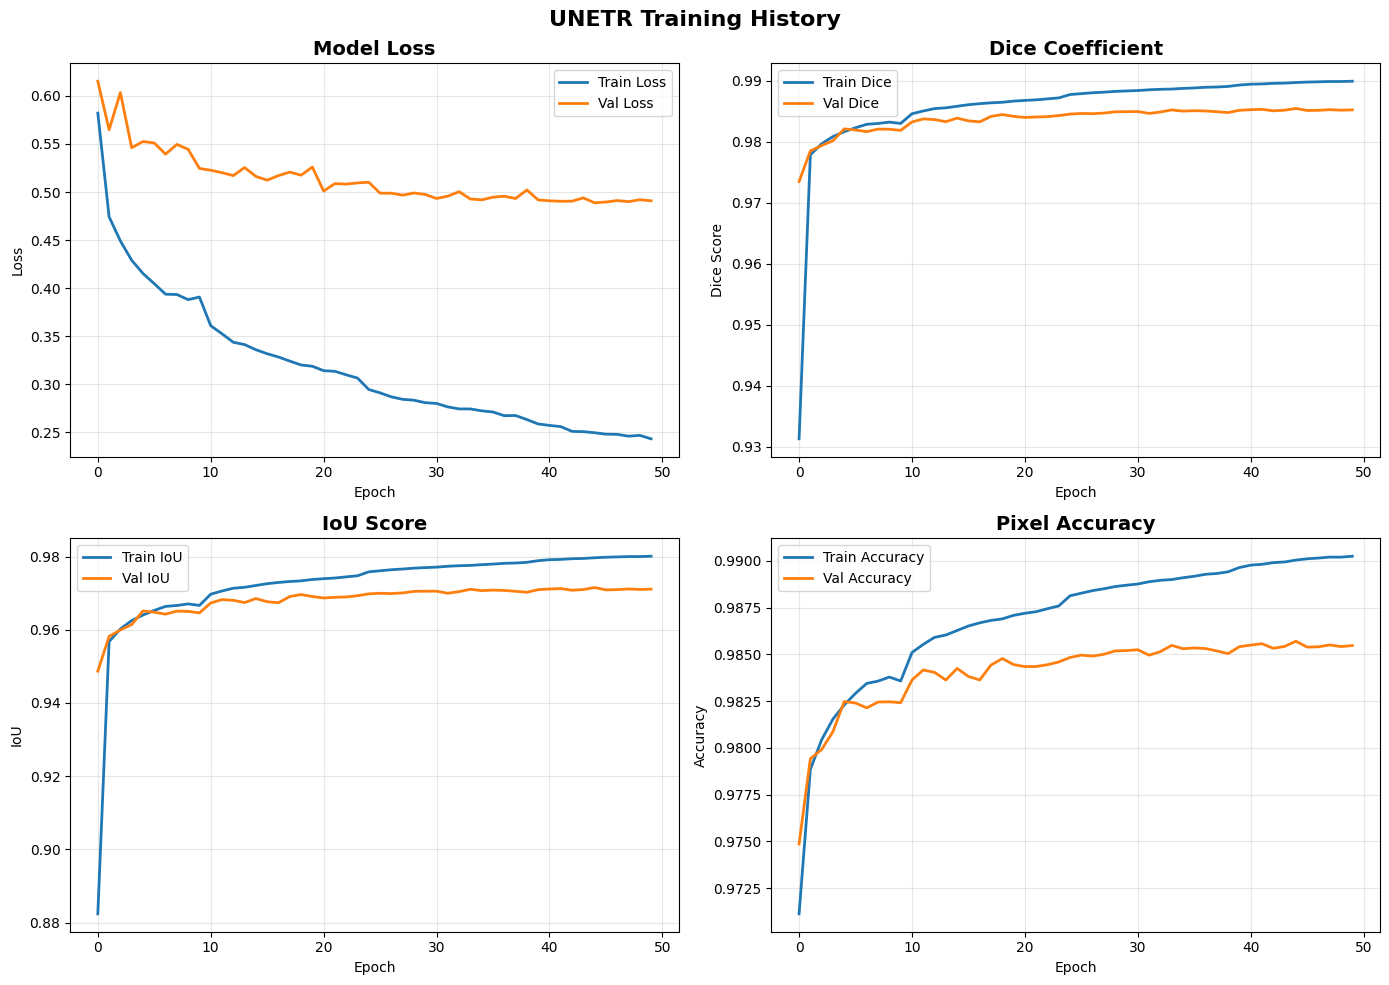

In [24]:
import matplotlib.pyplot as plt
import os

print("="*70)
print("📈 PLOTTING TRAINING HISTORY")
print("="*70)

# Check if training actually finished and 'history' exists
if 'history' in locals():
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # 1. Loss
    # Try to handle different key names (keras sometimes uses 'loss' or 'dice_loss')
    loss_key = 'loss' if 'loss' in history.history else list(history.history.keys())[0]
    val_loss_key = 'val_' + loss_key
    
    axes[0, 0].plot(history.history.get(loss_key, []), label='Train Loss', linewidth=2)
    axes[0, 0].plot(history.history.get(val_loss_key, []), label='Val Loss', linewidth=2)
    axes[0, 0].set_title('Model Loss', fontsize=14, fontweight='bold')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)

    # 2. Dice Coefficient
    axes[0, 1].plot(history.history.get('dice_coefficient', []), label='Train Dice', linewidth=2)
    axes[0, 1].plot(history.history.get('val_dice_coefficient', []), label='Val Dice', linewidth=2)
    axes[0, 1].set_title('Dice Coefficient', fontsize=14, fontweight='bold')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Dice Score')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)

    # 3. IoU Score
    axes[1, 0].plot(history.history.get('iou_score', []), label='Train IoU', linewidth=2)
    axes[1, 0].plot(history.history.get('val_iou_score', []), label='Val IoU', linewidth=2)
    axes[1, 0].set_title('IoU Score', fontsize=14, fontweight='bold')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('IoU')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)

    # 4. Accuracy
    axes[1, 1].plot(history.history.get('accuracy', []), label='Train Accuracy', linewidth=2)
    axes[1, 1].plot(history.history.get('val_accuracy', []), label='Val Accuracy', linewidth=2)
    axes[1, 1].set_title('Pixel Accuracy', fontsize=14, fontweight='bold')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('Accuracy')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)

    plt.suptitle('UNETR Training History', fontsize=16, fontweight='bold')
    plt.tight_layout()
    
    # CORRECTED SAVE PATH: Saves to your 'processed_data' folder
    save_path = os.path.join(config.PROCESSED_PATH, 'unetr_training_history.png')
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"✅ Plot saved to: {save_path}")
    plt.show()

else:
    print("⚠️ No training history found. Did the model finish training?")

# Evaluate on Test Set

In [18]:
import os
import tensorflow as tf
import gc

print("="*70)
print("📊 EVALUATING UNETR ON TEST SET")
print("="*70)

# Clear any existing models from memory
tf.keras.backend.clear_session()
gc.collect()

# Use weights file instead of full model (more memory efficient)
weights_path = os.path.join(config.PROCESSED_PATH, 'unetr_best_model.weights.h5')
print(f"Looking for weights at: {weights_path}")
print(f"File exists: {os.path.exists(weights_path)}")

if os.path.exists(weights_path):
    try:
        # Build model architecture
        print("\n🔨 Building UNETR model architecture...")
        best_model = build_unetr_model()
        print("✅ Model architecture built!")
        
        # Compile model
        print("\n⚙️ Compiling model...")
        best_model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=config.LEARNING_RATE),
            loss=dice_focal_loss,
            metrics=[dice_coefficient, iou_score, 'accuracy']
        )
        print("✅ Model compiled!")
        
        # Load weights
        print(f"\n📥 Loading weights from: {weights_path}")
        best_model.load_weights(weights_path)
        print("✅ Weights loaded successfully!")
        
        # Create test generator
        print("\n📊 Creating test data generator...")
        test_gen = DiskDataGenerator(
            split_type='test',
            batch_size=config.BATCH_SIZE,
            shuffle=False,
            augment=False
        )
        print(f"✅ Test generator created: {len(test_gen)} batches")
        
        # Evaluate
        print("\n🔍 Evaluating on test set...")
        test_results = best_model.evaluate(test_gen, verbose=1)
        
        print("\n" + "="*70)
        print("📊 TEST RESULTS")
        print("="*70)
        print(f"Test Loss: {test_results[0]:.4f}")
        print(f"Test Dice Coefficient: {test_results[1]:.4f}")
        print(f"Test IoU Score: {test_results[2]:.4f}")
        print(f"Test Accuracy: {test_results[3]:.4f}")
        print("="*70)
        
    except Exception as e:
        print(f"❌ Error: {e}")
        import traceback
        traceback.print_exc()
else:
    print(f"❌ Weights file not found at: {weights_path}")

📊 EVALUATING UNETR ON TEST SET
Looking for weights at: /mnt/d/Segmentation_TF/Processed_data/unetr_best_model.weights.h5
File exists: True

🔨 Building UNETR model architecture...
✅ Model architecture built!

⚙️ Compiling model...
✅ Model compiled!

📥 Loading weights from: /mnt/d/Segmentation_TF/Processed_data/unetr_best_model.weights.h5
✅ Weights loaded successfully!

📊 Creating test data generator...
✅ Test generator created: 822 batches

🔍 Evaluating on test set...


2025-12-05 09:58:46.253855: I external/local_xla/xla/service/service.cc:163] XLA service 0x7f24800027f0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-12-05 09:58:46.253883: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA RTX A4000, Compute Capability 8.6
2025-12-05 09:58:46.369481: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-12-05 09:58:46.739583: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91600
2025-12-05 09:58:48.239900: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_2', 72 bytes spill stores, 72 bytes spill loads

2025-12-05 09:58:48.357633: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : 

  3/822 ━━━━━━━━━━━━━━━━━━━━ 45s 55ms/step - accuracy: 0.9926 - dice_coefficient: 0.9925 - iou_score: 0.9852 - loss: 0.4570 

I0000 00:00:1764907132.850814  257445 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


822/822 ━━━━━━━━━━━━━━━━━━━━ 53s 53ms/step - accuracy: 0.9851 - dice_coefficient: 0.9848 - iou_score: 0.9704 - loss: 0.5004

📊 TEST RESULTS
Test Loss: 0.5004
Test Dice Coefficient: 0.9848
Test IoU Score: 0.9704
Test Accuracy: 0.9851


# Per-Class Evaluation

In [19]:
import numpy as np

def evaluate_per_class(model, generator, class_names):
    """Evaluate model performance per class using the disk generator"""
    print(f"📊 Evaluating per-class metrics across {len(generator)} batches...")
    
    # Initialize accumulators for global calculation
    # We sum intersections/unions across all batches to get a true global score
    total_intersection = {name: 0.0 for name in class_names}
    total_union_dice = {name: 0.0 for name in class_names}
    total_union_iou = {name: 0.0 for name in class_names}
    
    # Iterate through the generator
    for i in range(len(generator)):
        x_batch, y_batch = generator[i]
        
        # Get predictions for this batch
        preds_batch = model.predict(x_batch, verbose=0)
        
        for j, class_name in enumerate(class_names):
            # Threshold predictions (probability > 0.5 becomes 1, else 0)
            pred_class = (preds_batch[..., j] > 0.5).astype(np.float32)
            true_class = y_batch[..., j]
            
            # Calculate intersection and union for this batch
            intersection = np.sum(pred_class * true_class)
            union_dice = np.sum(pred_class) + np.sum(true_class)
            union_iou = union_dice - intersection
            
            # Add to global totals
            total_intersection[class_name] += intersection
            total_union_dice[class_name] += union_dice
            total_union_iou[class_name] += union_iou
            
        # Simple progress indicator
        if (i + 1) % 10 == 0:
            print(f"   Processed batch {i+1}/{len(generator)}...", end='\r')
            
    print(f"\n✅ Evaluation complete.")

    # Calculate final Global Scores
    dice_scores = {}
    iou_scores = {}
    
    for class_name in class_names:
        # Dice formula: 2*I / (Sum + Smooth)
        dice = (2. * total_intersection[class_name] + 1e-6) / (total_union_dice[class_name] + 1e-6)
        
        # IoU formula: I / (U + Smooth)
        iou = (total_intersection[class_name] + 1e-6) / (total_union_iou[class_name] + 1e-6)
        
        dice_scores[class_name] = dice
        iou_scores[class_name] = iou
        
    return dice_scores, iou_scores

# --- Execution ---
class_names = ['Background', 'Necrotic', 'Edema', 'Enhancing']

print("="*70)
print("PER-CLASS EVALUATION (MEMORY EFFICIENT)")
print("="*70)

# Use 'test_gen' instead of X_test/y_test_cat
dice_scores, iou_scores = evaluate_per_class(best_model, test_gen, class_names)

for class_name in class_names:
    print(f"\n{class_name}:")
    print(f"   Dice Score: {dice_scores[class_name]:.4f}")
    print(f"   IoU Score: {iou_scores[class_name]:.4f}")

print(f"\nMean Dice Score: {np.mean(list(dice_scores.values())):.4f}")
print(f"Mean IoU Score: {np.mean(list(iou_scores.values())):.4f}")
print("="*70)

PER-CLASS EVALUATION (MEMORY EFFICIENT)
📊 Evaluating per-class metrics across 822 batches...
   Processed batch 820/822...
✅ Evaluation complete.

Background:
   Dice Score: 0.9956
   IoU Score: 0.9912

Necrotic:
   Dice Score: 0.5523
   IoU Score: 0.3815

Edema:
   Dice Score: 0.6598
   IoU Score: 0.4923

Enhancing:
   Dice Score: 0.5926
   IoU Score: 0.4211

Mean Dice Score: 0.7001
Mean IoU Score: 0.5715


# Visualize Predictions

Visualizing 5 random samples from 'test' set...


2025-12-05 10:03:04.681377: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot', 788 bytes spill stores, 788 bytes spill loads

2025-12-05 10:03:04.917407: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_98', 940 bytes spill stores, 940 bytes spill loads

2025-12-05 10:03:04.972251: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_6', 1176 bytes spill stores, 1128 bytes spill loads

2025-12-05 10:03:04.992275: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_5', 1048 bytes spill stores, 1048 bytes spill loads



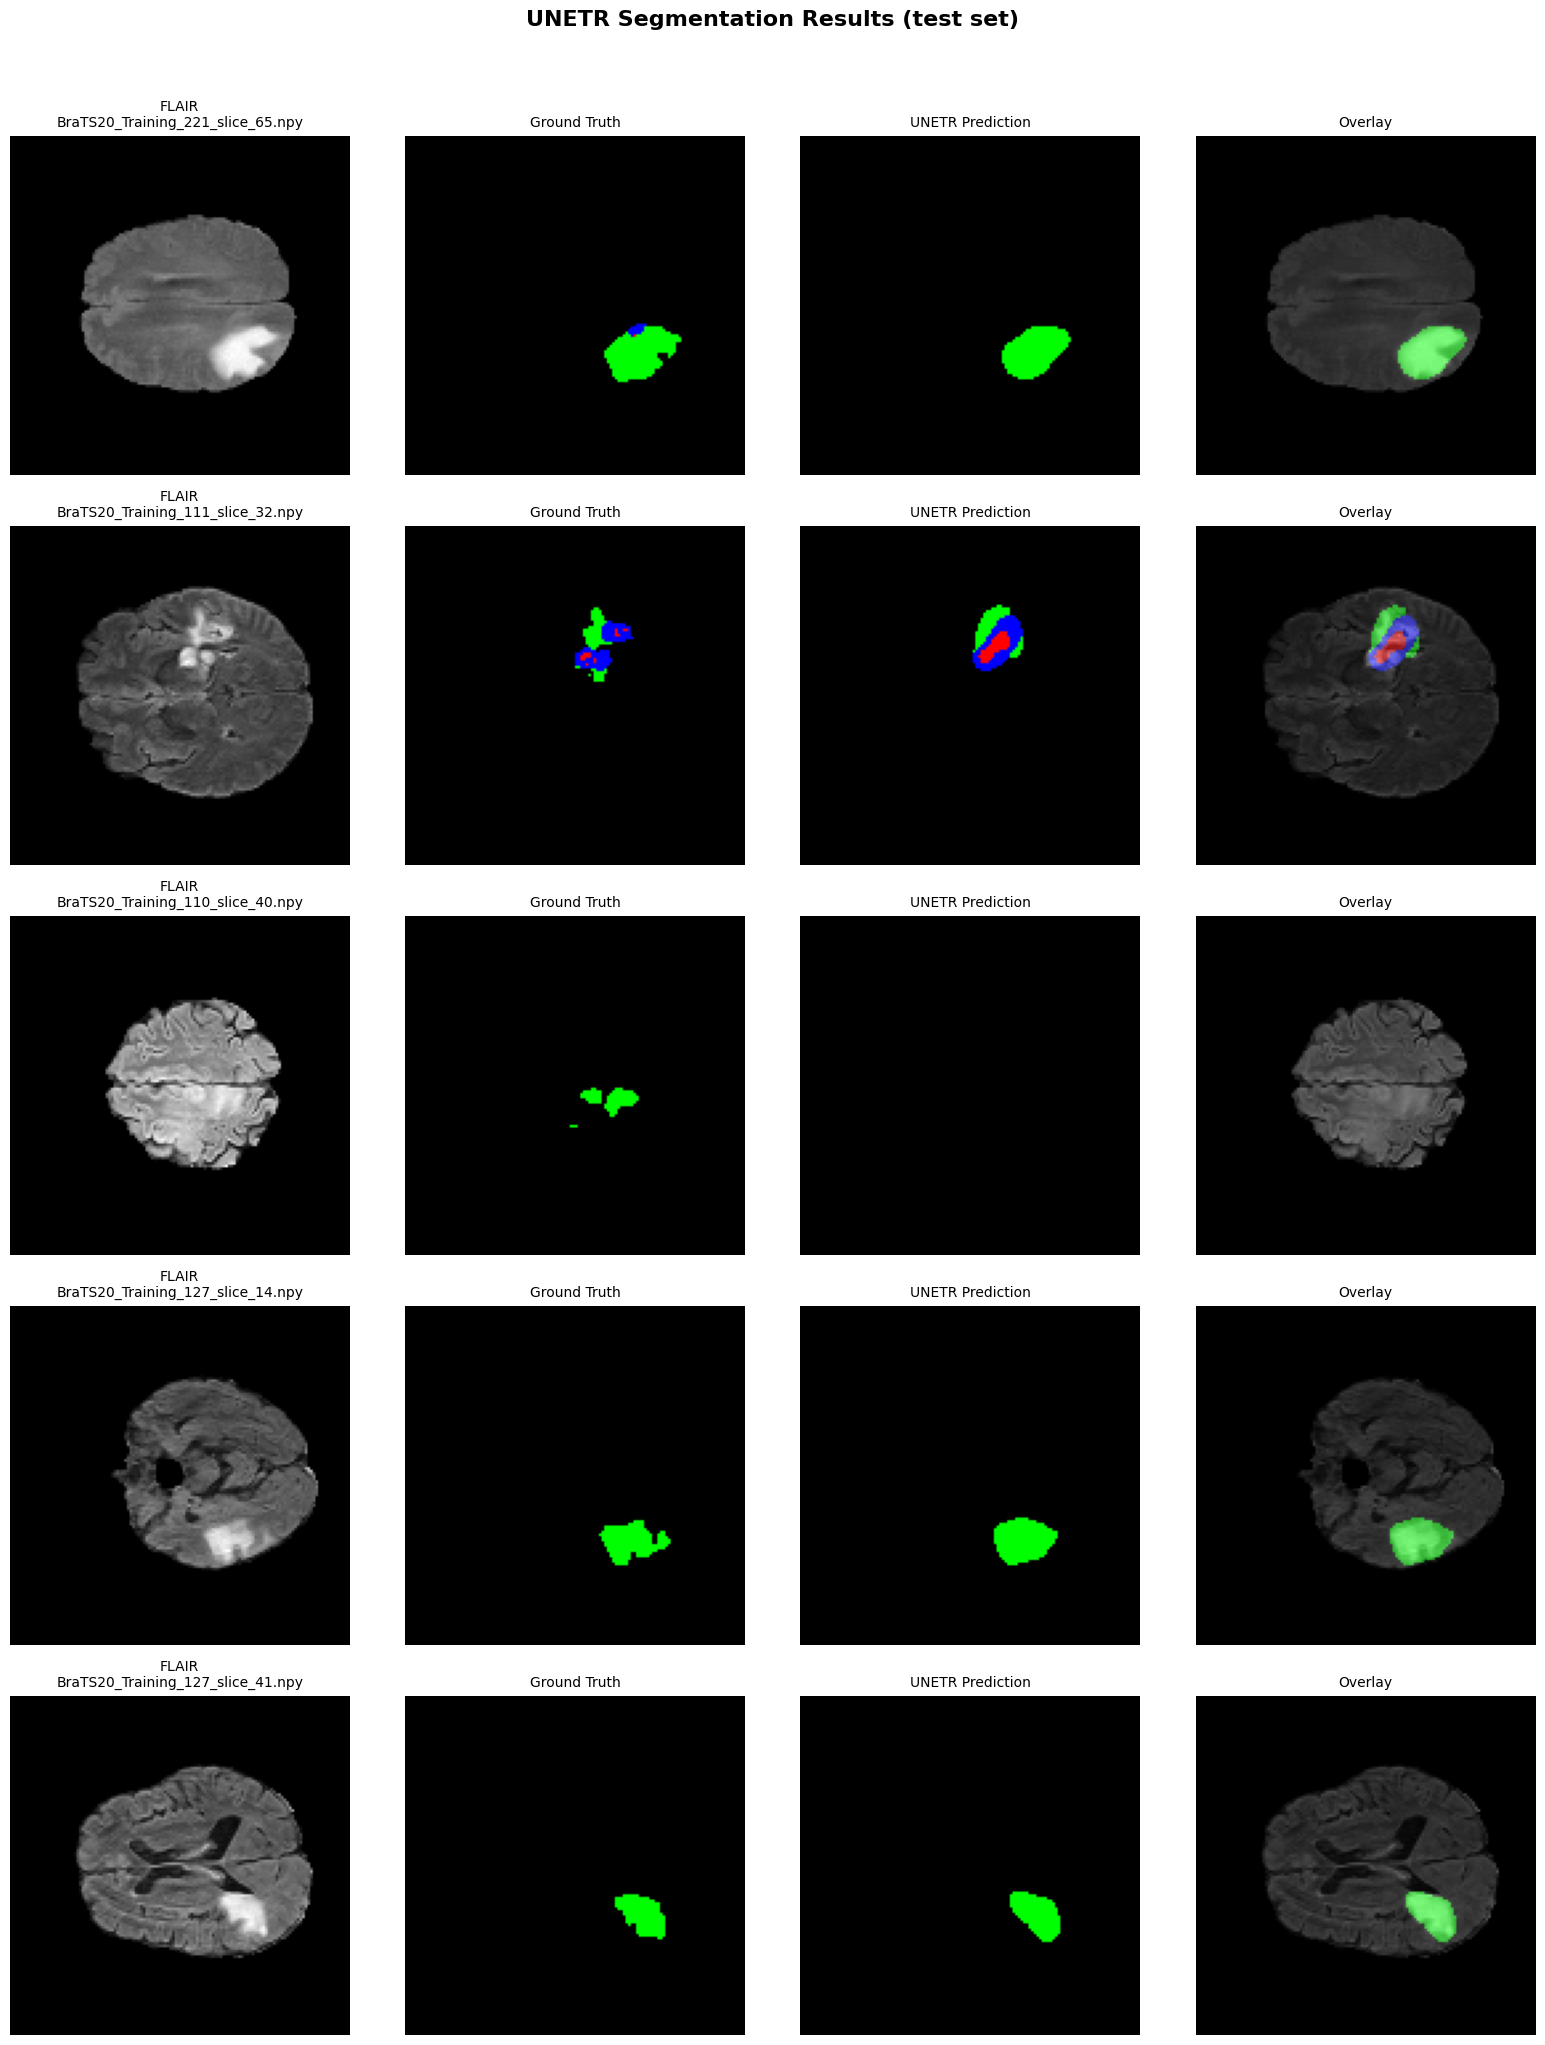

✅ Predictions saved to: /mnt/d/Segmentation_TF/Processed_data/unetr_predictions.png


In [20]:


def plot_predictions_from_disk(model, split_type='test', num_samples=5):
    """
    Visualize model predictions by loading random samples directly from disk.
    This prevents memory errors by avoiding loading the entire dataset.
    """
    # Paths to your saved data
    image_dir = os.path.join(config.PROCESSED_PATH, split_type, 'images')
    mask_dir = os.path.join(config.PROCESSED_PATH, split_type, 'masks')
    
    # Get all filenames
    all_files = sorted(os.listdir(image_dir))
    total_files = len(all_files)
    
    if total_files == 0:
        print("❌ No files found to visualize!")
        return

    # Select random indices
    indices = np.random.choice(total_files, num_samples, replace=False)
    
    # Color map for segmentation
    # 0: Background (Black), 1: Necrotic (Red), 2: Edema (Green), 3: Enhancing (Blue)
    colors = np.array([
        [0, 0, 0],       
        [255, 0, 0],     
        [0, 255, 0],     
        [0, 0, 255]      
    ])
    
    fig, axes = plt.subplots(num_samples, 4, figsize=(16, 4*num_samples))
    
    print(f"Visualizing {num_samples} random samples from '{split_type}' set...")
    
    for i, idx in enumerate(indices):
        filename = all_files[idx]
        
        # 1. Load data from disk
        img_path = os.path.join(image_dir, filename)
        mask_path = os.path.join(mask_dir, filename)
        
        img = np.load(img_path)   # Shape: (128, 128, 4)
        mask = np.load(mask_path) # Shape: (128, 128) -> Integer labels
        
        # 2. Predict
        # Add batch dimension: (128, 128, 4) -> (1, 128, 128, 4)
        input_img = np.expand_dims(img, axis=0)
        pred_prob = model.predict(input_img, verbose=0)[0]
        
        # Convert probabilities to class labels: (128, 128, 4) -> (128, 128)
        pred_mask = np.argmax(pred_prob, axis=-1)
        
        # 3. Map Integer Labels to Colors
        # mask is already integers, so we just apply colors
        true_colored = colors[mask.astype(int)]
        pred_colored = colors[pred_mask.astype(int)]
        
        # 4. Plotting
        # Column 1: FLAIR Input (Channel 3)
        axes[i, 0].imshow(img[:, :, 3], cmap='gray')
        axes[i, 0].set_title(f'FLAIR\n{filename}', fontsize=10)
        axes[i, 0].axis('off')
        
        # Column 2: Ground Truth
        axes[i, 1].imshow(true_colored.astype(np.uint8))
        axes[i, 1].set_title('Ground Truth', fontsize=10)
        axes[i, 1].axis('off')
        
        # Column 3: Prediction
        axes[i, 2].imshow(pred_colored.astype(np.uint8))
        axes[i, 2].set_title('UNETR Prediction', fontsize=10)
        axes[i, 2].axis('off')
        
        # Column 4: Overlay (FLAIR + Prediction)
        axes[i, 3].imshow(img[:, :, 3], cmap='gray')
        axes[i, 3].imshow(pred_colored.astype(np.uint8), alpha=0.5)
        axes[i, 3].set_title('Overlay', fontsize=10)
        axes[i, 3].axis('off')
    
    plt.suptitle(f'UNETR Segmentation Results ({split_type} set)', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    
    # Save to processed_data folder
    save_path = os.path.join(config.PROCESSED_PATH, 'unetr_predictions.png')
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"✅ Predictions saved to: {save_path}")

# Run the function
# Note: X_test and y_test are no longer needed as arguments
plot_predictions_from_disk(best_model, split_type='test', num_samples=5)

# Confusion Matrix

📊 GENERATING CONFUSION MATRIX (SAMPLED)
Processing 50 batches...
   Processed 50/50 batches...
✅ Collected 328152 pixels for evaluation.
Calculating Confusion Matrix...


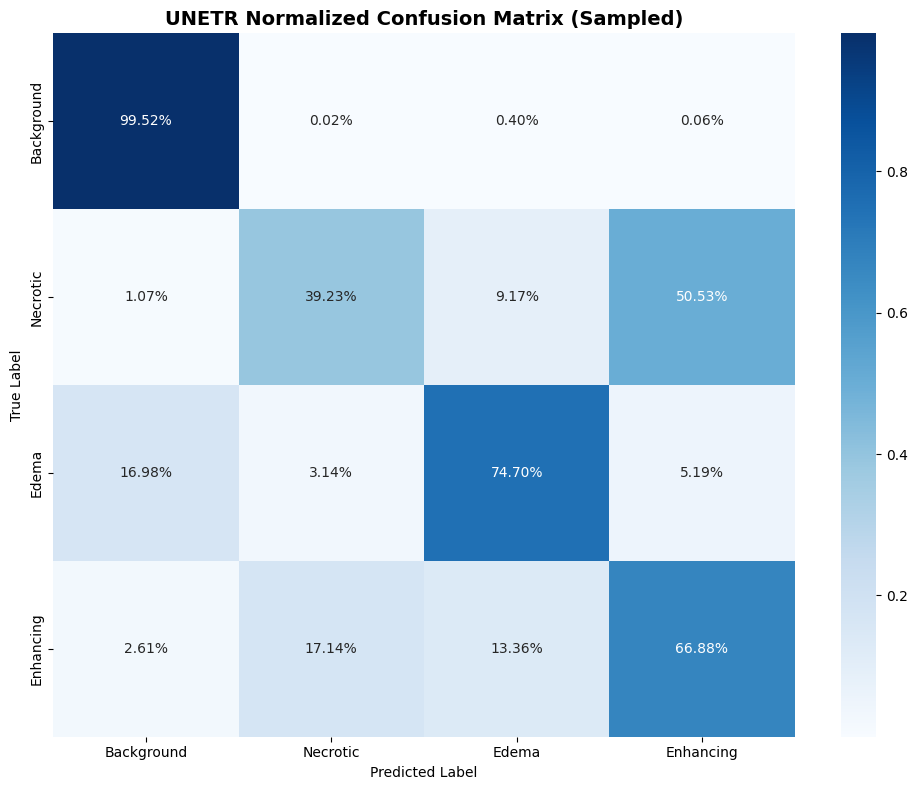

✅ Confusion matrix saved to: /mnt/d/Segmentation_TF/Processed_data/unetr_confusion_matrix.png

CLASSIFICATION REPORT
              precision    recall  f1-score   support

  Background     0.9950    0.9952    0.9951    316733
    Necrotic     0.3821    0.3923    0.3872       938
       Edema     0.8099    0.7470    0.7771      8947
   Enhancing     0.4790    0.6688    0.5582      1534

    accuracy                         0.9852    328152
   macro avg     0.6665    0.7008    0.6794    328152
weighted avg     0.9858    0.9852    0.9854    328152



In [21]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os

print("="*70)
print("📊 GENERATING CONFUSION MATRIX (SAMPLED)")
print("="*70)

# Define class names if not already defined
class_names = ['Background', 'Necrotic', 'Edema', 'Enhancing']

# Configuration for sampling
# We cannot load ALL pixels into memory (it would be billions).
# We will process a specific number of batches and sample pixels from them.
BATCHES_TO_PROCESS = 50  # Process 50 batches (approx 800 images)
SAMPLE_RATE = 0.1        # Keep 10% of pixels from each image (randomly)

all_true = []
all_pred = []

print(f"Processing {BATCHES_TO_PROCESS} batches...")

for i in range(min(len(test_gen), BATCHES_TO_PROCESS)):
    # Get a single batch
    x_batch, y_batch = test_gen[i]
    
    # Predict
    p_batch = best_model.predict(x_batch, verbose=0)
    
    # Convert probabilities to class labels (integers)
    # Shape becomes: (batch_size, 128, 128)
    true_labels = np.argmax(y_batch, axis=-1).flatten()
    pred_labels = np.argmax(p_batch, axis=-1).flatten()
    
    # Randomly sample pixels to save memory
    # This creates a boolean mask to select ~10% of the pixels
    mask = np.random.random(true_labels.shape) < SAMPLE_RATE
    
    all_true.extend(true_labels[mask])
    all_pred.extend(pred_labels[mask])
    
    # Progress bar
    if (i + 1) % 5 == 0:
        print(f"   Processed {i+1}/{BATCHES_TO_PROCESS} batches...", end='\r')

print(f"\n✅ Collected {len(all_true)} pixels for evaluation.")

# Convert lists to numpy arrays for sklearn
all_true = np.array(all_true)
all_pred = np.array(all_pred)

# --- Confusion Matrix ---
print("Calculating Confusion Matrix...")
cm = confusion_matrix(all_true, all_pred)

# Normalize (Row-wise)
# Add 1e-7 to avoid division by zero for missing classes
cm_normalized = cm.astype('float') / (cm.sum(axis=1)[:, np.newaxis] + 1e-7)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)

plt.title('UNETR Normalized Confusion Matrix (Sampled)', fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()

# Save to processed data folder
save_path = os.path.join(config.PROCESSED_PATH, 'unetr_confusion_matrix.png')
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"✅ Confusion matrix saved to: {save_path}")

# --- Classification Report ---
print("\n" + "="*70)
print("CLASSIFICATION REPORT")
print("="*70)
print(classification_report(all_true, all_pred, target_names=class_names, digits=4))
print("="*70)